# Basic usage

This tutorial demonstrates the basic usage of the `raves` Python package.

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

from raves import raves, run_ART, run_MoDART
from raves.src.compute_MoDART import plot_T60
from raves.src.utils.raves_io import visualize_mesh

## Step 1: Choose an environment

To begin with, let us choose the environment to be analyzed: one of the examples provided with this repository.
The `DampenedMiddle` environment consists of three rectangular rooms of comparable size, where the middle room is the least reverberant.
Several variants are provided, with differing levels of surface discretization; `DampenedMiddle_20_patches` is the coarsest one, with the fewest surface patches.

The pre-processing step expects to find three files in the environment folder: `materials.csv`, `mesh.mtl`, and `mesh.obj`.
The format specifications of these input files are detailed in `README.md`.

In [2]:
environment_folder = os.path.join('..', 'example environments', 'DampenedMiddle_20_patches')

The following line will allow you to visualize the 3D mesh of the environment.
The visualization opens in a separate window.
This function requires some optional dependencies, and will only work if you have installed `raves` with the command
```
pip install raves[mesh_vis]
```

In [3]:
visualize_mesh(environment_folder)

## Step 2: Pre-processing

Having selected the folder we want to analyze, let's run the pre-processing step.
Note that the ART surface integration will be skipped if ART kernels are already present in the folder (as is the case for the provided example).
If you want to run the integration anyway, overwriting any existing data, you can use the `overwrite` argument.

After either loading or computing the ART kernels and related data, the MoD-ART analysis will be run.
In the console output of this function, you will see that each frequency band is analyzed in turn.
In each band, the process will first construct the state transition matrix of the ART model, and then locate its (real, positive) eigenvalues of largest magnitude.
The search is conducted economically, iteratively using larger numbers of estimates until a reverberation time below the stopping threshold is found.

In [4]:

raves(environment_folder)

Running `compute_ART` in the environment "DampenedMiddle_20_patches"
8 cores available. Pool will use 4 SUB-processes.

Core ART files already exist. They will be read and re-used.
Current material data will be read and used to make new frequency-band kernels.
If you want to overwrite the existing core files, pass the argument `--overwrite` to the script.


Running `compute_MoDART` in the environment "DampenedMiddle_20_patches"

Analyzing frequency band #1.
	Generating full state transition matrix.
	Eigenvalue search (right eigenvectors).
		Searching with 4 estimates.
			Lowest found T60 is 210% of stopping value.
		Searching with 8 estimates.
			Lowest found T60 is 134% of stopping value.
		Searching with 16 estimates.
			Lowest found T60 is 111% of stopping value.
		Searching with 32 estimates.
			Lowest found T60 is 80% of stopping value.
	Eigenvalue search (left eigenvectors).
	Rearranging and scaling results.

Analyzing frequency band #2.
	Generating full state transition matrix.


Let's display the results of the analysis.  
This plot will show the $T_{60}$ of all energy modes (i.e., slopes of the acoustic energy decay) found in the analysis.
The analysis is performed separately for each frequency band, and energy modes are grouped accordingly in the plot.

Plotting results.


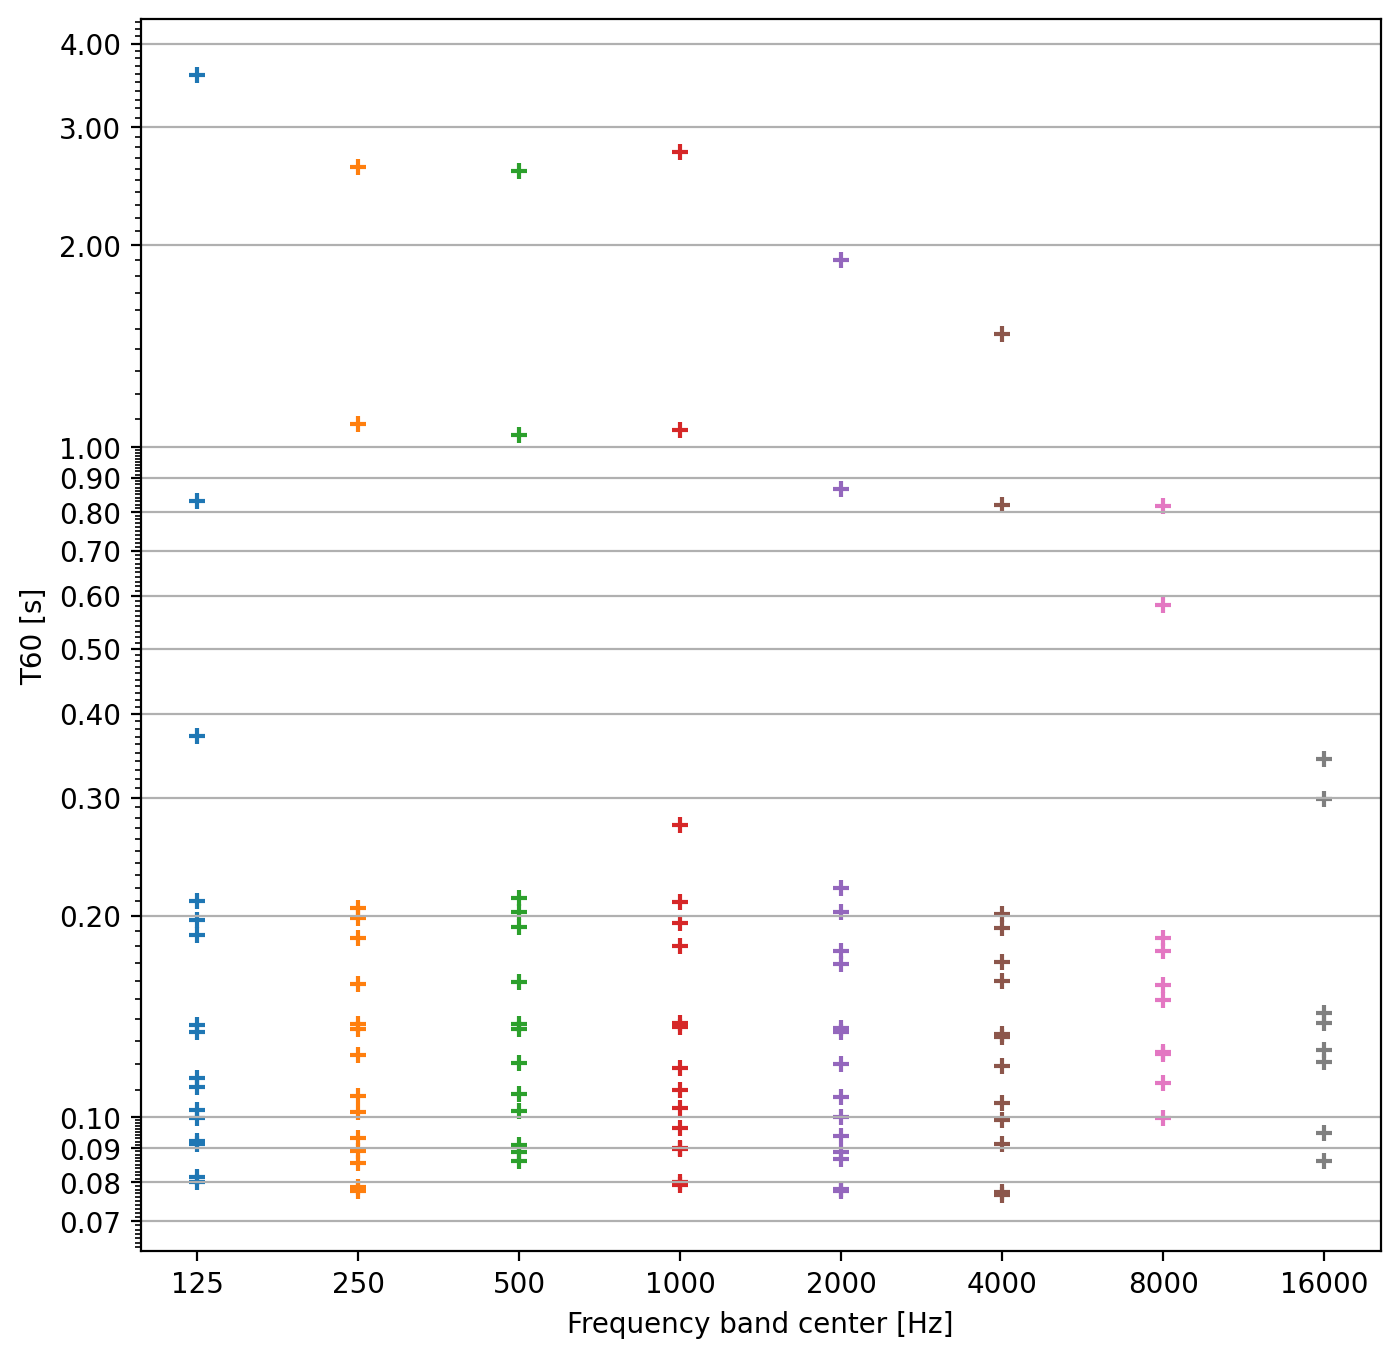

In [5]:
plot_T60(environment_folder, show_figure=True)

## Step 3: Echogram generation

You may have noticed that we did not specify the positions of sound sources and listeners within the environment.
The processing we have performed so far is an analysis of the environment as a whole, and the energy modes shown in the plot above are position-independent characteristics.

Now, let us define a few positions for sound sources and listeners, and evaluate point-to-point reverberation between them.

In [6]:
source_positions = np.array([[2.1, 1.9, 1.5],
                             [5.8, 4.1, 1.5],
                             [7.2, 6.5, 1.5]])
listener_positions = np.array([[3., 3.5, 1.75],
                               [9., 3.5, 1.75],
                               [9., 9.5, 1.75],])

We are going to express reverberation in the form of "echograms".
In other words, we will evaluate the envelopes of the point-to-point room impulse responses' energy, devoid of phase information.  
In order to capture the frequency-dependent effects of surface material properties and air absorption, we will generate separate echograms for each analyzed frequency band.
The echograms we are going to produce will thus be arrays of shape `(S, L, B, T)`, where:
* `S` is the number of sound source positions;
* `L` is the number of listener positions;
* `B` is the number of frequency bands;
* `T` is the duration of the echograms, in samples.

Let's start by specifying the length of time over which we want to evaluate energy decay, and the sample rate to be used by the echograms.
> **_NOTE:_**  The sample rate specified here is **not** an audio rate in the conventional sense. Its main effects in this context are reflected in the discretization of propagation times within the ART model, and in the temporal resolution of the resulting energy envelope.

In [7]:
# Duration of the echograms to be displayed, in seconds.
echogram_duration = 1.0
# Sample rate used for the echograms. Mostly relevant to avoid rounding errors in the propagation delays.
echogram_sample_rate = 1e4

### Step 3a: TD-ART

We will first evaluate the echograms using regular (time-domain) acoustic radiance transfer, as a reference.  
We also record the runtime of this operation, to compare it with MoD-ART.

Internally, the `run_ART` function is going to:
1. Load the ART pre-processing results from the specified folder;
2. Trace rays from each sound source position, taking note of which propagation paths receive acoustic energy, how much, and after how much delay;
3. Trace rays from each listener position, taking note of which propagation paths provide acoustic energy, how much, and after how much delay;
4. Assemble echograms for each frequency band using the iterative TD-ART algorithm;
5. Return the resulting echograms alongside the frequency band centers, used for plotting.

In [8]:
start_time = time.time()
ART_echograms, frequencies = run_ART(environment_folder, source_positions, listener_positions,
                                     echogram_sample_rate=echogram_sample_rate,
                                     echogram_duration=echogram_duration)
ART_runtime = time.time() - start_time

Running `run_ART` in the environment "DampenedMiddle_20_patches"
Processing source 1
	No output folder specified.
	Computing ray-tracing...
Processing source 2
	No output folder specified.
	Computing ray-tracing...
Processing source 3
	No output folder specified.
	Computing ray-tracing...
Processing listener 1
	No output folder specified.
	Computing ray-tracing...
Processing listener 2
	No output folder specified.
	Computing ray-tracing...
Processing listener 3
	No output folder specified.
	Computing ray-tracing...
All components ready. Assembling echograms.
	Frequency band 1...
	Frequency band 2...
	Frequency band 3...
	Frequency band 4...
	Frequency band 5...
	Frequency band 6...
	Frequency band 7...
	Frequency band 8...
Adding line-of-sight components where unobstructed.


### Step 3b: MoD-ART

Now, we will evaluate the echograms using the modal decomposition of acoustic radiance transfer.

Internally, the `run_MoDART` function is going to:
1. Load the MoD-ART pre-processing results (including the modes we plotted) from the specified folder;
2. Trace rays from each sound source position like before, but this time use the results to evaluate the energy mode residues;
3. Trace rays from each listener position like before, but this time use the results to evaluate the energy mode residues;;
4. Assemble echograms for each frequency band as a simple sum of weighted exponential terms;
5. Return the resulting echograms alongside the frequency band centers and full MoD-ART data, which we ignore for this exercise.

In [9]:
start_time = time.time()
MoDART_echograms, _, _ = run_MoDART(environment_folder, source_positions, listener_positions,
                                    echogram_sample_rate=echogram_sample_rate,
                                    echogram_duration=echogram_duration)
MoDART_runtime = time.time() - start_time

Running `run_MoDART` in the environment "DampenedMiddle_20_patches"
Processing source 1
	No output folder specified.
	Computing ray-tracing...
	Computing residues...
Processing source 2
	No output folder specified.
	Computing ray-tracing...
	Computing residues...
Processing source 3
	No output folder specified.
	Computing ray-tracing...
	Computing residues...
Processing listener 1
	No output folder specified.
	Computing ray-tracing...
	Computing residues...
Processing listener 2
	No output folder specified.
	Computing ray-tracing...
	Computing residues...
Processing listener 3
	No output folder specified.
	Computing ray-tracing...
	Computing residues...
All residues ready. Assembling echograms.
Adding line-of-sight components where unobstructed.


Let's compare the runtime of the two approaches...

In [10]:
print('TD-ART took {:.3f} seconds to generate the echograms.'.format(ART_runtime))
print('MoD-ART took {:.3f} seconds to generate the echograms.'.format(MoDART_runtime))
print('MoD-ART took {:.2f}% as long as TD-ART.'.format(100. * MoDART_runtime / ART_runtime))

TD-ART took 28.625 seconds to generate the echograms.
MoD-ART took 0.635 seconds to generate the echograms.
MoD-ART took 2.22% as long as TD-ART.


## Step 4: Plot results

Finally, let's visually compare the echograms produced by the two approaches.  
We will plot both the echograms themselves, and their energy decay curves (backwards integration).

We will only plot the echograms in one frequency band, for all combinations of sound source and listener positions.

In [11]:
displayed_band_idx = 5
displayed_duration = echogram_duration / 2

# Prepare a time axis for the plots.
time_axis = np.arange(0, ART_echograms.shape[-1]) / echogram_sample_rate
num_bands = len(frequencies)
num_sources = len(source_positions)
num_listeners = len(listener_positions)
# Number of (echogram) samples actually shown displayed the plots:
displayed_len = min(len(time_axis), int(displayed_duration * echogram_sample_rate))

### Step 4a: Echograms

First, the echograms themselves.  
We will use the same y-axis extent in all subplots.

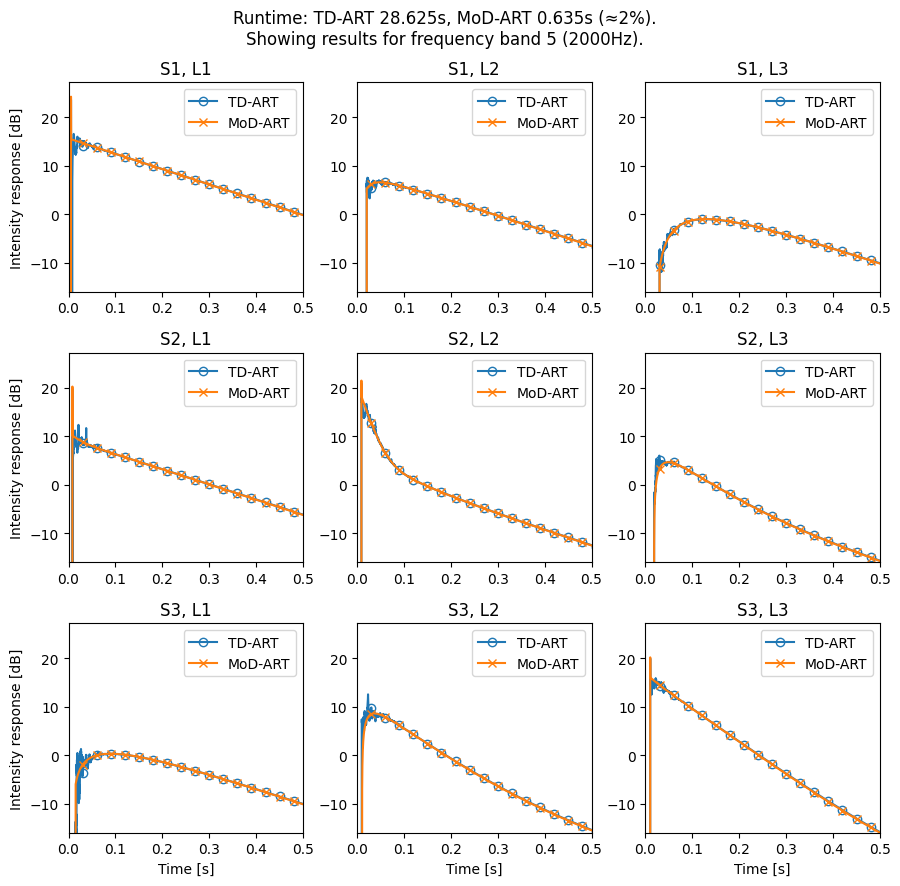

In [12]:
# Clip the echograms strictly above 0 and convert to dB.
ART_echograms_clipped = np.clip(ART_echograms, 1e-20, None)
MoDART_echograms_clipped = np.clip(MoDART_echograms, 1e-20, None)
ART_echograms_dB = 10 * np.log10(ART_echograms_clipped)
MoDART_echograms_dB = 10 * np.log10(MoDART_echograms_clipped)

# Consider the extent of the dB range to be plotted.
max_extent = max(np.max(ART_echograms_dB[:, :, displayed_band_idx-1, :displayed_len]),
                 np.max(MoDART_echograms_dB[:, :, displayed_band_idx-1, :displayed_len]))
min_extent = min(np.min(ART_echograms_dB[:, :, displayed_band_idx-1, displayed_len]),
                 np.min(MoDART_echograms_dB[:, :, displayed_band_idx-1, displayed_len]))

fig, ax = plt.subplots(num_sources, num_listeners,
                       figsize=(3*num_listeners, 3*num_sources))

for s in range(num_sources):
    for l in range(num_listeners):
        ax[s, l].plot(time_axis, ART_echograms_dB[s, l, displayed_band_idx-1],
                      label='TD-ART', marker='o', fillstyle='none',
                      markevery=int(3e-2 * echogram_sample_rate))
        ax[s, l].plot(time_axis, MoDART_echograms_dB[s, l, displayed_band_idx-1],
                      label='MoD-ART', marker='x',
                      markevery=int(3e-2 * echogram_sample_rate))
        
        ax[s, l].legend()
        ax[s, l].set_xlim(0, displayed_duration)
        ax[s, l].set_ylim(min_extent, max_extent + 3)
        
        ax[s, l].set_title('S{}, L{}'.format(s+1, l+1))
        if l == 0:
            ax[s, l].set_ylabel('Intensity response [dB]')
        if s == num_sources-1:
            ax[s, l].set_xlabel('Time [s]')

plt.suptitle('Runtime: TD-ART {:.3f}s, MoD-ART {:.3f}s (≈{:.0f}%).'.format(ART_runtime, MoDART_runtime, 100. * MoDART_runtime / ART_runtime)
             + '\nShowing results for frequency band {} ({:.0f}Hz).'.format(displayed_band_idx, frequencies[displayed_band_idx-1]))
plt.tight_layout()

plt.show()

### Step 4b: Energy decay curves

Now, we plot the backwards integration of the echograms.
Note that we do not normalize these by the total energy, in order to compare the relative overall loudness of different configurations.
The leftmost value (at time 0) of each plot is the total energy of that point-to-point room impulse response in the selected frequency band. 
Again, we will use the same y-axis extent in all subplots.

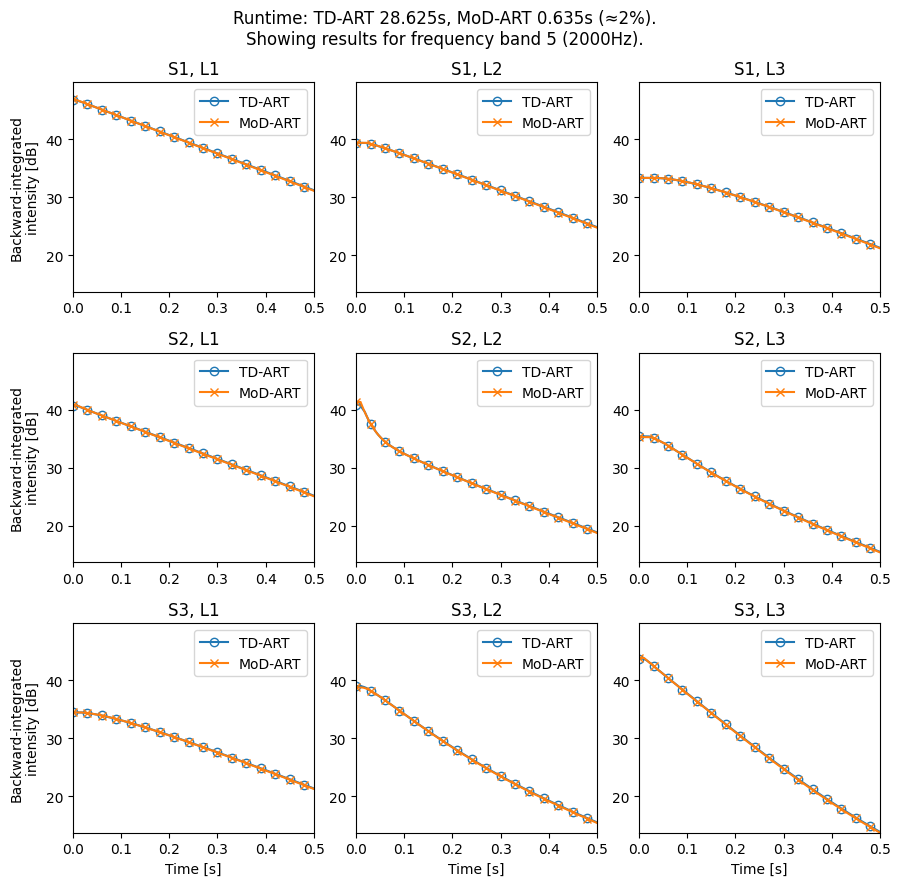

In [13]:
ART_EDCs = np.cumsum(ART_echograms[:, :, :, ::-1], axis=-1)[:, :, :, ::-1]
MoDART_EDCs = np.cumsum(MoDART_echograms[:, :, :, ::-1], axis=-1)[:, :, :, ::-1]
ART_EDCs_clipped = np.clip(ART_EDCs, 1e-20, None)
MoDART_EDCs_clipped = np.clip(MoDART_EDCs, 1e-20, None)
ART_EDCs_dB = 10 * np.log10(ART_EDCs_clipped)
MoDART_EDCs_dB = 10 * np.log10(MoDART_EDCs_clipped)

# Consider the extent of the dB range to be plotted.
max_extent = max(np.max(ART_EDCs_dB[:, :, displayed_band_idx-1, 0]),
                 np.max(MoDART_EDCs_dB[:, :, displayed_band_idx-1, 0]))
min_extent = min(np.min(ART_EDCs_dB[:, :, displayed_band_idx-1, displayed_len]),
                 np.min(MoDART_EDCs_dB[:, :, displayed_band_idx-1, displayed_len]))

fig, ax = plt.subplots(num_sources, num_listeners,
                       figsize=(3*num_listeners, 3*num_sources))

for s in range(num_sources):
    for l in range(num_listeners):
        ax[s, l].plot(time_axis, ART_EDCs_dB[s, l, displayed_band_idx-1],
                      label='TD-ART', marker='o', fillstyle='none',
                      markevery=int(3e-2 * echogram_sample_rate))
        ax[s, l].plot(time_axis, MoDART_EDCs_dB[s, l, displayed_band_idx-1],
                      label='MoD-ART', marker='x',
                      markevery=int(3e-2 * echogram_sample_rate))
        
        ax[s, l].legend()
        ax[s, l].set_xlim(0, displayed_duration)
        ax[s, l].set_ylim(min_extent, max_extent + 3)
        
        ax[s, l].set_title('S{}, L{}'.format(s+1, l+1))
        if l == 0:
            ax[s, l].set_ylabel('Backward-integrated\nintensity [dB]')
        if s == num_sources-1:
            ax[s, l].set_xlabel('Time [s]')

plt.suptitle('Runtime: TD-ART {:.3f}s, MoD-ART {:.3f}s (≈{:.0f}%).'.format(ART_runtime, MoDART_runtime, 100. * MoDART_runtime / ART_runtime)
             + '\nShowing results for frequency band {} ({:.0f}Hz).'.format(displayed_band_idx, frequencies[displayed_band_idx-1]))
plt.tight_layout()

plt.show()